-Graphics-
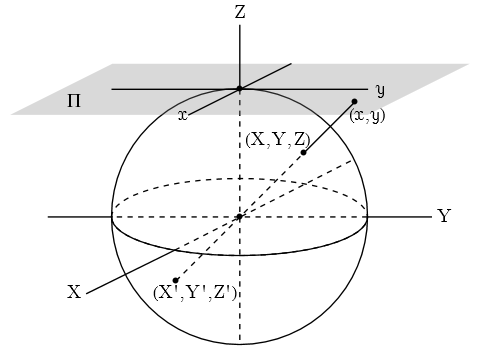

In [40]:
plot = Graphics[{
  Circle[{0,0},1],
  Circle[{0, 0}, {1, 0.3}, {Pi, 2Pi}],
  {Dashed, Circle[{0, 0}, {1, 0.3}, {2Pi, 4Pi}]},
  {Dashed, Line[{{0,1},{0,-1}}]},
  {Dashed, Line[{{1,0},{-1,0}}]},
  {Gray, Opacity[0.3], Polygon[{{-1,1.2},{-1.8,0.8},{1,0.8},{1.8,1.2}}]}, Text[Style["\[CapitalPi]", 16, FontFamily -> "CMU Serif Upright"], {-1.3, .9}],
  Line[{{1,0},{1.5,0}}], Text[Style["Y", 14, FontFamily -> "CMU Serif Upright"], {1.6, 0}],
  Line[{{-1,0},{-1.5,0}}],
  Line[{{0,1},{0,1.5}}], Text[Style["Z", 14, FontFamily -> "CMU Serif Upright"], {0, 1.6}],
  {Dashed, Line[{{-0.51,-0.26},{0.89,0.45}}]},
  Line[{{-0.51,-0.26},{-1.2,-0.6}}], Text[Style["X", 14, FontFamily -> "CMU Serif Upright"], {-1.3, -0.6}],
  Line[{{0.4,1.2},{-0.4,0.8}}], Text[Style["x", 14, FontFamily -> "CMU Serif Upright"], {-0.45, 0.8}],
  Line[{{-1,1},{1,1}}], Text[Style["y", 14, FontFamily -> "CMU Serif Upright"], {1.1, 1}],
  {PointSize -> Medium, Point[{{0,0},{0.9, 0.9},{0,1},{0.5,0.5},{-0.5,-0.5}}]},
  {Dashed, Line[{{-0.5,-0.5},{0.5,0.5}}]},
  Line[{{0.5,0.5},{0.9,0.9}}], Text[Style["(x,y)", 14, FontFamily -> "CMU Serif Upright"], {1, 0.8}],
  Text[Style["(X',Y',Z')", 14, FontFamily -> "CMU Serif Upright"], {-0.35, -0.6}],
  Text[Style["(X,Y,Z)", 14, FontFamily -> "CMU Serif Upright"], {0.3, 0.6}]
}]

In [41]:
Export["poincareCompactification.pdf", plot]

poincareCompactification.pdf

-Graphics-
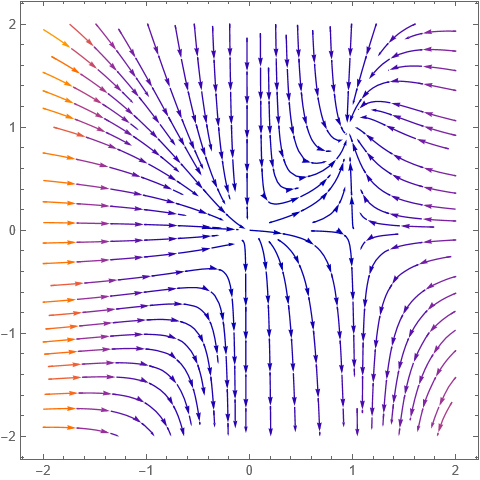

In [400]:
r = 0.1; a = 0.1; s = 0.1; K = 0.1; n = 0.1; q = 0.1;
A = a/K;
Q = (q*n)/r;
B = s/r;

plot1 = StreamPlot[{u^2((1-u)(u^2+A^2)-Q*u*v), B(u-v)(u^2+A^2)v}, {u, -2, 2}, {v, -2, 2}]

{{-2., -2.}, {-2., -1.5}, {-2., -1.}, {-2., -0.5}, {-2., 0.}, {-2., 0.5}, {-2., 1.}, 
 
>   {-2., 1.5}, {-2., 2.}, {-1.5, -2.}, {-1.5, -1.5}, {-1.5, -1.}, {-1.5, -0.5}, 
 
>   {-1.5, 0.}, {-1.5, 0.5}, {-1.5, 1.}, {-1.5, 1.5}, {-1.5, 2.}, {-1., -2.}, 
 
>   {-1., -1.5}, {-1., -1.}, {-1., -0.5}, {-1., 0.}, {-1., 0.5}, {-1., 1.}, {-1., 1.5}, 
 
>   {-1., 2.}, {-0.5, -2.}, {-0.5, -1.5}, {-0.5, -1.}, {-0.5, -0.5}, {-0.5, 0.}, 
 
>   {-0.5, 0.5}, {-0.5, 1.}, {-0.5, 1.5}, {-0.5, 2.}, {0., -2.}, {0., -1.5}, {0., -1.}, 
 
>   {0., -0.5}, {0., 0.}, {0., 0.5}, {0., 1.}, {0., 1.5}, {0., 2.}, {0.5, -2.}, 
 
>   {0.5, -1.5}, {0.5, -1.}, {0.5, -0.5}, {0.5, 0.}, {0.5, 0.5}, {0.5, 1.}, {0.5, 1.5}, 
 
>   {0.5, 2.}, {1., -2.}, {1., -1.5}, {1., -1.}, {1., -0.5}, {1., 0.}, {1., 0.5}, 
 
>   {1., 1.}, {1., 1.5}, {1., 2.}, {1.5, -2.}, {1.5, -1.5}, {1.5, -1.}, {1.5, -0.5}, 
 
>   {1.5, 0.}, {1.5, 0.5}, {1.5, 1.}, {1.5, 1.5}, {1.5, 2.}, {2., -2.}, {2., -1.5}, 
 
>   {2., -1.}, {2., -0.5}, {2., 0.}, {2., 0.5}, {2., 1.}, {2., 1.5}, {2., 2.}}
-Graphics3D-
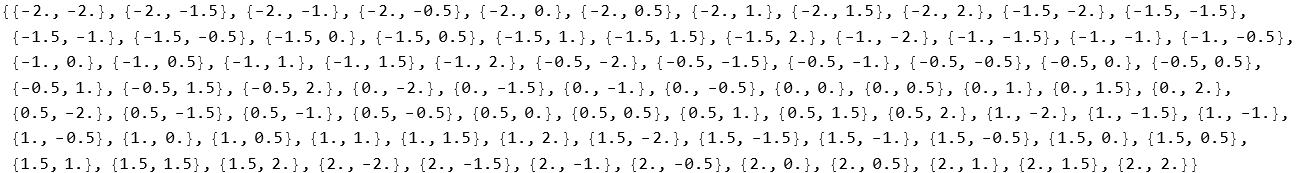
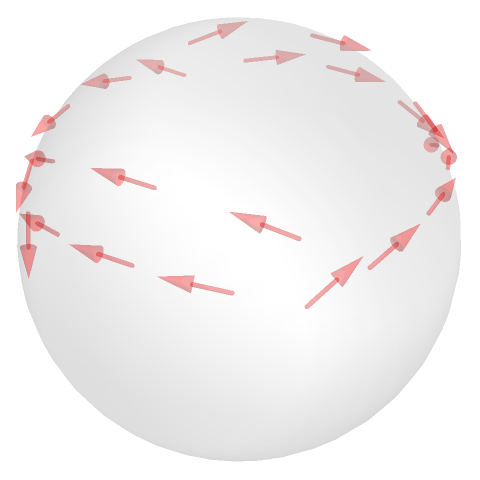

In [323]:
f[x_, y_] := {y, -x + x^3};

stereographic[{x_, y_}] := {x, y, 1}/Sqrt[1 + x^2 + y^2];

(* Jacobiano de la proyección *)
DF[x_, y_] := 
  D[stereographic[{u, v}], {{u, v}}] /. {u -> x, v -> y};

(* Empuje del vector al espacio tangente de la esfera *)
pushforward[x_, y_] := DF[x, y].f[x, y];

(* ======================= *)
(* 3. Muestreo             *)
(* ======================= *)

(* Seleccionamos puntos en el plano *)
grid = Tuples[Range[-2, 2, .5], 2]

(* Proyectamos puntos a la esfera y empujamos los vectores *)
data = Table[
   {
    stereographic[{x, y}],
    pushforward[x, y]
   },
   {x, -2, 2, 1}, {y, -2, 2, 1}
   ] // Flatten[#, 1] &;

(* ======================= *)
(* 4. Visualización        *)
(* ======================= *)

Graphics3D[
 {
  Opacity[0.2], Sphere[{0, 0, 0}, 1], (* esfera unidad *)
  
  Red, 
  Arrow[Tube[{#1, #1 + 0.3 Normalize[#2]}, 0.01]] & @@@ data
  },
 Boxed -> False, SphericalRegion -> True, Lighting -> "Neutral"
]
